In [ ]:
import json
import os
import itertools
import numpy as np

# Relative path: run this notebook from the folder holding the data CSVs, since
# cell 0 of the original notebook reads them relatively too.
NB = 'BOLA.ipynb'
if not os.path.exists(NB):
    raise FileNotFoundError(
        "Not found: %r from %r.\n"
        "Run this notebook from the data folder, or set NB manually."
        % (NB, os.getcwd()))


_nb = json.load(open(NB))
_srcs = [''.join(c['source']) for c in _nb['cells'] if c['cell_type'] == 'code']


def _cell_defining(name, fallback):
    for s in _srcs:
        if ('def %s(' % name) in s:
            return s
    return _srcs[fallback]


_g = {'__name__': '__main__', 'product': itertools.product}
_needed = [_srcs[0],                                   # data, discretisation, r
           _srcs[1],                                   # value iteration -> Q
           _cell_defining('mpc_optimize', 3),          # imports + MPC helpers
           _cell_defining('calculate_cost_predict_k_step_with_noise', 4)]  # BOLA
for _i, _s in enumerate(_needed):
    exec(compile(_s, '<orig_%d>' % _i, 'exec'), _g)
for _k, _v in _g.items():
    if not _k.startswith('__'):
        globals()[_k] = _v
assert 'calculate_cost_predict_k_step_with_noise' in globals(), \
    "the original notebook must define calculate_cost_predict_k_step_with_noise"
BOLA_RAW = calculate_cost_predict_k_step_with_noise
print("BOLA loaded from the original notebook:", BOLA_RAW.__name__)
print('  signature:', list(BOLA_RAW.__code__.co_varnames[:BOLA_RAW.__code__.co_argcount]))


gamma = 0.95
N_EXO = N_price * N_mis                      # 100 exogenous bins (price, mismatch)
S_PHYS = N_EXO * N_SoC                       # 2100 states
DSOC = SoC_max / (N_SoC - 1)                 # SoC grid spacing
W_P = (max_price - min_price + 1e-3) / N_price     # bin widths, as in the original
W_M = (max_mis - min_mis + 1e-3) / N_mis

# Flattened cost table, taken unchanged from the original `r` (bin-centre costs).
R_FLAT = r.reshape(N_EXO, N_SoC, N_a).reshape(S_PHYS, N_a).copy()
R3 = R_FLAT.reshape(N_EXO, N_SoC, N_a)

.
soc_grid = np.arange(N_SoC) * DSOC
ACT_EFF = np.clip(action_set[None, :], -soc_grid[:, None], SoC_max - soc_grid[:, None])
SOC_NEXT = np.rint(np.clip(soc_grid[:, None] + ACT_EFF, 0, SoC_max) / DSOC).astype(int)
assert np.allclose(soc_grid[SOC_NEXT], np.clip(soc_grid[:, None] + ACT_EFF, 0, SoC_max))
ACT_IDX = np.rint((ACT_EFF - action_set[0]) / (action_set[1] - action_set[0])).astype(int)
assert np.allclose(action_set[ACT_IDX], ACT_EFF)


T_EVAL_START, T_EVAL_LEN = 1952, 3000
T_EVAL_END = T_EVAL_START + T_EVAL_LEN
T_MAX = min(len(price), len(mis))
TRAIN = np.arange(T_EVAL_END + 1000, T_MAX)

# Realised series and their bin indices, cached once.
PRICE = np.asarray(price[:T_MAX], float)
MIS = np.asarray(mis[:T_MAX], float)
PB = np.clip(((PRICE - min_price) / W_P).astype(int), 0, N_price - 1)
MB = np.clip(((MIS - min_mis) / W_M).astype(int), 0, N_mis - 1)
EXO = PB * N_mis + MB                        # exogenous bin at every date



def bola_cost(k, sigma, seed=None, start=T_EVAL_START, length=T_EVAL_LEN):
    """Cumulative cost of BOLA at horizon k under relative forecast error sigma."""
    if seed is not None:
        np.random.seed(seed)
    return BOLA_RAW(Q, k, price, mis, action_set, SoC_max, N_price, N_mis, N_SoC,
                    min_price, max_price, min_mis, max_mis, sigma, sigma,
                    start=start, length=length)




In [ ]:


def fit_markov(x, idx, K, alpha=1.0):
    """Count how often bin b is followed by bin b' at the time steps in idx, then
    normalise each row. Returns a K x K matrix with entry [b, b'] equal to
    P(next bin = b' | current bin = b). alpha adds a pseudo-count to every pair
    so unobserved transitions get a small probability rather than exactly zero."""
    C = np.full((K, K), alpha)
    np.add.at(C, (x[idx[:-1]], x[idx[1:]]), 1.0)
    return C / C.sum(axis=1, keepdims=True)


P_PRICE = fit_markov(PB, TRAIN, N_price)             
P_MIS = fit_markov(MB, TRAIN, N_mis)                 


P_EXO = (P_PRICE[:, None, :, None] * P_MIS[None, :, None, :]).reshape(N_EXO, N_EXO)
assert np.allclose(P_EXO.sum(1), 1)


_w, _v = np.linalg.eig(P_EXO.T)
MU = np.real(_v[:, np.argmax(np.real(_w))]); MU = np.abs(MU) / np.abs(MU).sum()


_rp = np.random.default_rng(7)
_sel = _rp.choice(len(TRAIN), size=min(4000, len(TRAIN)), replace=False)
AT_T = TRAIN[_sel]
AT_P, AT_M, AT_E = PRICE[AT_T], MIS[AT_T], EXO[AT_T]     # price, mismatch, bin
PRIOR_COST = (np.maximum(0.0, -(AT_M[:, None] + action_set[None, :]))
              * AT_P[:, None])                            # (4000, 9) exact costs


FLOOR_P, FLOOR_M = 1e-3 * W_P, 1e-3 * W_M


_ic, _jc = np.divmod(np.arange(N_EXO), N_mis)
P_TAB_C = min_price + (max_price - min_price) * (_ic + 0.5) / N_price
M_TAB_C = min_mis + (max_mis - min_mis) * (_jc + 0.5) / N_mis
R_TAB_C = np.maximum(0.0, -(M_TAB_C[:, None] + action_set[None, :])) * P_TAB_C[:, None]


# --- (iii) what a forecast tells us -----------------------------------------

def likelihood_and_rbar(z_p, z_m, sigma):
    """Given an observed forecast z = (z_p, z_m) with relative noise sigma,
    return two objects:

      L[e']    : likelihood of having observed z if the true value lay in bin e'.
                 Computed by summing the Gaussian density over the atoms of e'.
      rbar[e', a] : expected exact cost of action a, given the true value lies in
                 bin e' and z was observed -- i.e. the atom costs of bin e',
                 weighted by their posterior probability.

    At sigma = 0 the forecast is exact: L is a point mass on the observed bin and
    rbar is that bin's exact continuous cost."""
    if sigma <= 0.0:
        e = int(min(max((z_p - min_price) / W_P, 0), N_price - 1)) * N_mis \
            + int(min(max((z_m - min_mis) / W_M, 0), N_mis - 1))
        L = np.zeros(N_EXO); L[e] = 1.0
        rbar = R_TAB_C.copy()
        rbar[e] = np.maximum(0.0, -(z_m + action_set)) * z_p
        return L, rbar

    sp = np.maximum(sigma * np.abs(AT_P), FLOOR_P)
    sm = np.maximum(sigma * np.abs(AT_M), FLOOR_M)
    ll = (-0.5 * ((z_p - AT_P) / sp) ** 2 - np.log(sp)
          - 0.5 * ((z_m - AT_M) / sm) ** 2 - np.log(sm))
    ll -= ll.max()
    w = np.exp(ll)
    L = np.bincount(AT_E, weights=w, minlength=N_EXO)          # weight per bin
    cw = w[:, None] * PRIOR_COST
    rbar = np.stack([np.bincount(AT_E, weights=cw[:, j], minlength=N_EXO)
                     for j in range(len(action_set))], axis=1)
    pos = L > 0
    rbar[pos] /= L[pos][:, None]                               # weighted average
    rbar[~pos] = R_TAB_C[~pos]                                 # empty bins
    return L, rbar


def kernel_from_likelihood(L):
    """Posterior transition kernel given the forecast: combine the prior P_EXO
    with the likelihood L by Bayes' rule, row by row.
    kappa[e, e'] = P(next bin = e' | current bin = e, forecast observed)
                 proportional to P_EXO[e, e'] * L[e']."""
    K = P_EXO * L[None, :]
    s = K.sum(axis=1, keepdims=True)
    return np.where(s > 0, K / np.maximum(s, 1e-300), P_EXO)




In [ ]:


def sample_dictionary(N, rng, sigma=0.0):
    """Draw N kernels i.i.d. from nu, the law of the posterior kernel.
    Row e is built by: sampling a true next bin from P_EXO[e], picking an atom
    inside it, observing that atom through the noise channel, and taking row e of
    the resulting posterior. At sigma = 0 this collapses to a one-hot row."""
    out = []
    for _ in range(N):
        nxt = np.array([rng.choice(N_EXO, p=P_EXO[e]) for e in range(N_EXO)])
        if sigma <= 0:
            K = np.zeros((N_EXO, N_EXO)); K[np.arange(N_EXO), nxt] = 1.0
        else:
            K = np.empty((N_EXO, N_EXO))
            for e in range(N_EXO):
                cand = np.flatnonzero(AT_E == nxt[e])
                if len(cand) == 0:
                    K[e] = P_EXO[e]                  # no atom in that bin
                    continue
                j = rng.choice(cand)
                L, _ = likelihood_and_rbar(AT_P[j] * (1 + rng.normal(0, sigma)),
                                           AT_M[j] * (1 + rng.normal(0, sigma)), sigma)
                K[e] = kernel_from_likelihood(L)[e]
        out.append(K)
    return np.stack(out)


def observe_window(sigma, start, length, ell, seed):
    """Precompute, for every DATE in the horizon, the observed posterior kernel
    and the posterior costs rbar. One noise draw per date, shared by all windows
    containing that date. Returns (first date, kernels, costs)."""
    rng = np.random.default_rng(seed)
    us = np.arange(start, start + length + max(ell, 1) + 1)
    zp, zm = PRICE[us], MIS[us]
    if sigma > 0:
        zp = zp * (1 + rng.normal(0, sigma, len(us)))
        zm = zm * (1 + rng.normal(0, sigma, len(us)))
    out = [likelihood_and_rbar(zp[i], zm[i], sigma) for i in range(len(us))]
    Ks = np.stack([kernel_from_likelihood(o[0]) for o in out])
    Rb = np.stack([o[1] for o in out])
    return us[0], Ks, Rb

In [ ]:


def _bellman_min(GB, R=None):

    if R is None:
        R = R3
    best = None
    for a in range(N_a):
        cand = R[:, :, a][:, :, None] + GB[:, SOC_NEXT[:, a], :]
        best = cand if best is None else np.minimum(best, cand, out=best)
    return best.reshape(S_PHYS, -1)


def offline_vi(Kdict, ell, H=250, tol=1e-8, verbose=True):

    N = len(Kdict)

    if ell == 0:

        Kbar = Kdict.mean(axis=0)
        v = np.zeros(S_PHYS)
        for h in range(H):
            vn = _bellman_min(gamma * (Kbar @ v.reshape(N_EXO, N_SoC))[:, :, None])[:, 0]
            d = np.abs(vn - v).max(); v = vn
            if d < tol:
                break
        if verbose:
            print('  [offline l=0] %d iterations, delta = %.2e' % (h + 1, d))
        return v

    M = N ** (ell - 1)
    v = np.zeros((S_PHYS, N ** ell))
    for h in range(H):

        G2 = v.reshape(S_PHYS, M, N).mean(axis=2).reshape(N_EXO, N_SoC * M)
        vn = np.empty_like(v)
        for i0 in range(N):

            GB = gamma * (Kdict[i0] @ G2).reshape(N_EXO, N_SoC, M)
            vn[:, i0 * M:(i0 + 1) * M] = _bellman_min(GB)
        d = np.abs(vn - v).max(); v = vn
        if d < tol:
            break
    if verbose:
        print('  [offline l=%d] N=%d, |core|=%d, %d iterations, delta=%.2e'
              % (ell, N, v.size, h + 1, d))
    return v

In [ ]:

def online_scores(v, ell, s_flat, kaps, N, rbars=None):
    """Action scores at the current state, given the observed window.

    v      : offline array from STEP 3, shape (S_PHYS, N^l)
    s_flat : current physical state, flattened as e * N_SoC + so
    kaps   : (l, N_EXO, N_EXO) observed kernels kappa_0..kappa_{l-1}
    rbars  : (l+1, N_EXO, 9) posterior costs for dates t..t+l; None falls back
             on the bin-centre table R3
    Returns one score per action, to be minimised. Requires l >= 1; l = 0 goes
    through greedy_rollout (STEP 6)."""
    assert ell >= 1, "l = 0: use greedy_rollout, not online_scores"
    e_s, k_s = divmod(s_flat, N_SoC)
    R0 = R3 if rbars is None else rbars[0][:, ACT_IDX]        # reward at date t

    U = v
    for kk in range(ell - 1, 0, -1):

        Nk = N ** kk
        H = U.reshape(S_PHYS, Nk, N).mean(axis=2).reshape(N_EXO, N_SoC * Nk)
        GB = gamma * (kaps[kk] @ H).reshape(N_EXO, N_SoC, Nk)
        Rk = None if rbars is None else rbars[kk][:, ACT_IDX]
        U = _bellman_min(GB, Rk)

    # root: one coordinate left, and only the current (bin, SoC) is needed
    GB = gamma * (kaps[0] @ U.mean(axis=1).reshape(N_EXO, N_SoC))
    return R0[e_s, k_s, :] + GB[e_s, SOC_NEXT[k_s, :]]

In [ ]:

def _chain_kernels(kaps):

    M = [np.eye(N_EXO)]
    for h in range(len(kaps)):
        M.append(M[-1] @ kaps[h])
    return M  # longueur H+1


def bola_bayes_offline(K, N2, sigma=0.0, tol=1e-4, max_iter=500, seed=0,
                        verbose=False):

    rng = np.random.default_rng(seed)
    sigmas = [sample_dictionary(K, rng, sigma) for _ in range(N2)]     
    M_all = [_chain_kernels(sigmas[i]) for i in range(N2)]             

    R3_flat = R3.reshape(N_EXO, N_SoC * N_a)
    barC = np.empty((N2, K, N_EXO, N_SoC, N_a))
    for i in range(N2):
        for t in range(K):
            barC[i, t] = (M_all[i][t] @ R3_flat).reshape(N_EXO, N_SoC, N_a)

    J = np.zeros((N_EXO, N_SoC))
    for it in range(max_iter):
        J_next = np.zeros((N_EXO, N_SoC))
        for i in range(N2):
            U = M_all[i][K] @ J                      
            for t in range(K - 1, -1, -1):
                GB = (gamma * U)[:, :, None]
                U = _bellman_min(GB, barC[i, t]).reshape(N_EXO, N_SoC)
            J_next += U
        J_next /= N2
        delta = np.max(np.abs(J_next - J))
        J = J_next
        if verbose and it % 20 == 0:
            print('  BOLA-bayes VI iter %3d  |dJ|=%.3e' % (it, delta))
        if delta <= tol:
            break
    return J


def bola_bayes_block_actions(J, block, s_flat, kaps, rbars=None):
    """Etape en ligne (eq. 6) : etant donne l'etat courant et la prevision
    REELLE observee kaps[0..block-1] (et rbars[0..block] si continuous_reward),
    renvoie la SEQUENCE ENTIERE d'actions optimale a_0..a_{block-1} -- choisie
    une fois pour toutes, pas pas-a-pas."""
    e_s, k_s = divmod(s_flat, N_SoC)

    dist = np.zeros(N_EXO); dist[e_s] = 1.0
    dists = [dist]
    for h in range(block):
        dist = dist @ kaps[h]
        dists.append(dist)                           

    bar_r = []
    for t in range(block):
        Rt = R3 if rbars is None else rbars[t][:, ACT_IDX]
        bar_r.append(np.einsum('e,eka->ka', dists[t], Rt))
    bar_V_terminal = dists[block] @ J                 


    U = bar_V_terminal
    policies = []
    for t in range(block - 1, -1, -1):
        cand = bar_r[t] + gamma * U[SOC_NEXT]         
        a_star = np.argmin(cand, axis=1)
        U = cand[np.arange(N_SoC), a_star]
        policies.append(a_star)
    policies = policies[::-1]                         

    actions, k_cur = [], k_s
    for t in range(block):
        a = int(policies[t][k_cur])
        actions.append(a)
        k_cur = SOC_NEXT[k_cur, a]
    return actions


def bola_bayes_rollout(J, K, sigma, start=T_EVAL_START, length=T_EVAL_LEN,
                        soc0=5.0, seed=0, continuous_reward=True):
    """Deroule BOLA-avec-valeur-bayesienne : replanifie tous les K pas (pas a
    chaque pas comme RPTAS), execute le bloc entier, paie le cout REALISE.
    Un seul appel a observe_window pour toute la trajectoire, comme
    rptas_rollout -- meme bruit partage entre dates, meme protocole
    'common random numbers' que le reste du notebook."""
    u0, Ks, Rb = observe_window(sigma, start, length, K, seed)
    k = int(round(soc0 / DSOC))
    costs = []
    t = start
    while t < start + length:
        block = min(K, start + length - t)
        kaps = Ks[t + 1 - u0: t + 1 - u0 + block]
        rbars = Rb[t - u0: t - u0 + block + 1] if continuous_reward else None
        if len(kaps) < block or (rbars is not None and len(rbars) < block + 1):
            break
        actions = bola_bayes_block_actions(J, block, EXO[t] * N_SoC + k, kaps, rbars)
        for a in actions:
            costs.append(max(0.0, -(MIS[t] + ACT_EFF[k, a])) * PRICE[t])
            k = SOC_NEXT[k, a]
            t += 1
    return np.cumsum(costs)

In [ ]:

def mpc_scores(ell, s_flat, kaps, rbars=None, terminal=None):
    """Scores d'action pour du MPC a horizon `ell`. Meme signature que
    online_scores, moins N, plus `terminal` optionnel.

    ell      : horizon de planification / look-ahead
    s_flat   : etat physique courant, aplati en e * N_SoC + so
    kaps     : (ell, N_EXO, N_EXO) noyaux observes kappa_0..kappa_{ell-1}
    rbars    : (ell+1, N_EXO, 9) couts posterieurs pour les dates t..t+ell ;
               None retombe sur la table par centre de bin R3
    terminal : (N_EXO, N_SoC) valeur au-dela de la fenetre observee.
               None -> 0 partout (MPC pur, comportement original).
    Retourne un score par action, a minimiser.
    """
    assert ell >= 1, "l = 0 : utiliser greedy_rollout, pas mpc_scores"
    e_s, k_s = divmod(s_flat, N_SoC)
    R0 = R3 if rbars is None else rbars[0][:, ACT_IDX]

    U = np.zeros((N_EXO, N_SoC)) if terminal is None else np.asarray(terminal)

    for kk in range(ell - 1, 0, -1):
        GB = gamma * (kaps[kk] @ U)                      # (N_EXO, N_SoC)
        Rk = R3 if rbars is None else rbars[kk][:, ACT_IDX]
        U = np.min(Rk + GB[:, SOC_NEXT], axis=2)          # min sur l'action -> (N_EXO, N_SoC)

    GB = gamma * (kaps[0] @ U)
    return R0[e_s, k_s, :] + GB[e_s, SOC_NEXT[k_s, :]]


def mpc_rollout(ell, sigma, start=T_EVAL_START, length=T_EVAL_LEN,
                soc0=5.0, seed=0, continuous_reward=True, terminal=None):
    """Replanifie a chaque pas avec mpc_scores et paye le cout realise.
    Miroir exact de rptas_rollout (STEP 5) -- meme fenetre, memes
    recompenses, meme logique de rollout -- pour que la seule difference
    mesuree soit le choix de `terminal` (None = MPC pur ; array = MPC avec
    repli non adaptatif, cf. diagnostic ci-dessus)."""
    assert ell >= 1, "l = 0 : utiliser greedy_rollout (STEP 6)"
    u0, Ks, Rb = observe_window(sigma, start, length, ell, seed)
    k = int(round(soc0 / DSOC))
    costs = []
    for t in range(start, start + length):
        kaps = Ks[t + 1 - u0: t + 1 - u0 + ell]
        rbars = Rb[t - u0: t - u0 + ell + 1] if continuous_reward else None
        if len(kaps) < ell or (rbars is not None and len(rbars) < ell + 1):
            break
        a = int(np.argmin(mpc_scores(ell, EXO[t] * N_SoC + k, kaps, rbars, terminal)))
        costs.append(max(0.0, -(MIS[t] + ACT_EFF[k, a])) * PRICE[t])
        k = SOC_NEXT[k, a]
    return np.cumsum(costs)


def observe_raw_forecast(sigma, start, length, ell, seed):
    """Meme generation de bruit que observe_window (meme rng, meme formule
    multiplicative), mais renvoie directement les valeurs BRUTES zp, zm
    (prevision ponctuelle) au lieu du noyau/cout bayesien reconstruit sur
    les atomes. Reproduit EXACTEMENT le meme tirage pour une graine donnee."""
    rng = np.random.default_rng(seed)
    us = np.arange(start, start + length + max(ell, 1) + 1)
    zp, zm = PRICE[us].copy(), MIS[us].copy()
    if sigma > 0:
        zp = zp * (1 + rng.normal(0, sigma, len(us)))
        zm = zm * (1 + rng.normal(0, sigma, len(us)))
    return us[0], zp, zm


def mpc_ce_scores(k_s, zp_window, zm_window, terminal=None):
    """Scores d'action (equivalent-certain) pour le SoC courant k_s, premier
    pas de la fenetre. terminal : (N_SoC,) -- PAS (N_EXO, N_SoC), puisqu'il
    n'y a plus d'incertitude exogene ici (la prevision remplace le noyau)."""
    ell = len(zp_window)
    U = np.zeros(N_SoC) if terminal is None else np.asarray(terminal)
    for h in range(ell - 1, 0, -1):
        c_h = zp_window[h] * np.maximum(0.0, -(zm_window[h] + ACT_EFF))   # (N_SoC, N_a)
        cand = c_h + gamma * U[SOC_NEXT]
        U = cand.min(axis=1)
    c_0 = zp_window[0] * np.maximum(0.0, -(zm_window[0] + ACT_EFF))
    return c_0[k_s] + gamma * U[SOC_NEXT[k_s]]


def mpc_ce_rollout(ell, sigma, start=T_EVAL_START, length=T_EVAL_LEN,
                    soc0=5.0, seed=0, terminal=None):
    """MPC equivalent-certain, replanifie a chaque pas."""
    u0, zp, zm = observe_raw_forecast(sigma, start, length, ell, seed)
    k = int(round(soc0 / DSOC))
    costs = []
    for t in range(start, start + length):
        zpw = zp[t - u0: t - u0 + ell]
        zmw = zm[t - u0: t - u0 + ell]
        if len(zpw) < ell:
            break
        a = int(np.argmin(mpc_ce_scores(k, zpw, zmw, terminal)))
        costs.append(max(0.0, -(MIS[t] + ACT_EFF[k, a])) * PRICE[t])
        k = SOC_NEXT[k, a]
    return np.cumsum(costs)


def bola_ce_block_action(k_s, zp_window, zm_window, terminal=None):
    """Sequence d'actions optimale (bloc ENTIER, engagement open-loop) en
    equivalent-certain -- meme recursion que mpc_ce_scores, mais renvoie
    toute la sequence au lieu du seul premier coup."""
    ell = len(zp_window)
    U = np.zeros(N_SoC) if terminal is None else np.asarray(terminal)
    policies = []
    for h in range(ell - 1, -1, -1):
        c_h = zp_window[h] * np.maximum(0.0, -(zm_window[h] + ACT_EFF))
        cand = c_h + gamma * U[SOC_NEXT]
        a_star = np.argmin(cand, axis=1)
        U = cand[np.arange(N_SoC), a_star]
        policies.append(a_star)
    policies = policies[::-1]
    actions, k_cur = [], k_s
    for h in range(ell):
        a = int(policies[h][k_cur])
        actions.append(a)
        k_cur = SOC_NEXT[k_cur, a]
    return actions


def bola_ce_rollout(ell, sigma, start=T_EVAL_START, length=T_EVAL_LEN,
                     soc0=5.0, seed=0, terminal=None):
    """BOLA equivalent-certain, engagement par bloc de ell actions -- MEME
    pipeline (observe_raw_forecast) que mpc_ce_rollout : sert de reference
    'open-loop, meme information' pour le test closed-loop vs open-loop."""
    u0, zp, zm = observe_raw_forecast(sigma, start, length, ell, seed)
    k = int(round(soc0 / DSOC))
    costs = []
    t = start
    while t < start + length:
        block = min(ell, start + length - t)
        zpw = zp[t - u0: t - u0 + block]
        zmw = zm[t - u0: t - u0 + block]
        if len(zpw) < block:
            break
        actions = bola_ce_block_action(k, zpw, zmw, terminal)
        for a in actions:
            costs.append(max(0.0, -(MIS[t] + ACT_EFF[k, a])) * PRICE[t])
            k = SOC_NEXT[k, a]
            t += 1
    return np.cumsum(costs)


In [ ]:

def cost_exact(t):
    """Cout realise a la date t pour tout (SoC, action) : (N_SoC, N_a).
    C'est litteralement le cout facture par les rollouts."""
    return PRICE[t] * np.maximum(0.0, -(MIS[t] + ACT_EFF))



def bayes_terminal_J(ell, N2, sigma=0.0, tol=1e-4, max_iter=500, seed=0):
    """J(e, k) : cout-a-aller bayesien au-dela de l'horizon explicite.
    Point fixe de l'equation de Bellman bayesienne (Lu et al., eq. 4) pour un
    bloc couvrant les dates t..t+ell, la transition SORTANT de t+ell n'etant
    PAS observee (elle se propage donc par P_EXO, pas par un noyau tire).

    A ell = 0 : aucun noyau observe, l'equation se reduit EXACTEMENT a la
    value iteration standard sous P_EXO. C'est un theoreme, et c'est ce qui
    doit faire coincider RPTAS(0), MPC-bayes(0) et BOLA-bayes(0) -- a
    l'erreur de dictionnaire de RPTAS pres."""
    rng = np.random.default_rng(seed)
    R3f = R3.reshape(N_EXO, N_SoC * N_a)
    Ms = []
    for _ in range(N2):
        M = [np.eye(N_EXO)]
        if ell > 0:
            kaps = sample_dictionary(ell, rng, sigma)
            for h in range(ell):
                M.append(M[-1] @ kaps[h])
        Ms.append(M)
    barC = np.empty((N2, ell + 1, N_EXO, N_SoC, N_a))
    for i in range(N2):
        for h in range(ell + 1):
            barC[i, h] = (Ms[i][h] @ R3f).reshape(N_EXO, N_SoC, N_a)
    tails = [Ms[i][ell] @ P_EXO for i in range(N2)]

    J = np.zeros((N_EXO, N_SoC))
    for _ in range(max_iter):
        Jn = np.zeros((N_EXO, N_SoC))
        for i in range(N2):
            U = tails[i] @ J
            for h in range(ell, -1, -1):
                U = np.min(barC[i, h] + gamma * U[:, SOC_NEXT], axis=2)
            Jn += U
        Jn /= N2
        d = np.abs(Jn - J).max()
        J = Jn
        if d <= tol:
            break
    return J



def bayes_block_actions(J, ell, s_flat, kaps, rbars, r0):
    """Renvoie les ell+1 actions du bloc (dates t..t+ell).
    Le premier element est le coup du closed-loop, la liste entiere celui du
    open-loop : la recursion est LA MEME, donc l'egalite a ell = 0 est
    structurelle et n'a plus a etre imposee a la main.
    J = None -> valeur terminale nulle (ablation)."""
    e_s, k_s = divmod(s_flat, N_SoC)
    dist = np.zeros(N_EXO); dist[e_s] = 1.0
    dists = [dist]
    for h in range(ell):
        dists.append(dists[-1] @ kaps[h])           # dists[h] = loi de e_{t+h}

    bar_r = [r0]                                    # date t : cout EXACT
    for h in range(1, ell + 1):
        bar_r.append(np.einsum('e,eka->ka', dists[h], rbars[h][:, ACT_IDX]))

    # au-dela de t+ell la transition n'est pas observee -> P_EXO
    U = (dists[ell] @ P_EXO) @ J if J is not None else np.zeros(N_SoC)
    pol = []
    for h in range(ell, -1, -1):
        cand = bar_r[h] + gamma * U[SOC_NEXT]
        a = np.argmin(cand, axis=1)
        U = cand[np.arange(N_SoC), a]
        pol.append(a)
    pol = pol[::-1]

    acts, kc = [], k_s
    for h in range(ell + 1):
        a = int(pol[h][kc]); acts.append(a); kc = SOC_NEXT[kc, a]
    return acts


def rptas_scores(v, ell, s_flat, kaps, N, rbars, r0):
    """RPTAS : valeur hors-ligne indexee par la FENETRE de dictionnaire."""
    e_s, k_s = divmod(s_flat, N_SoC)
    if ell == 0:
        GB = gamma * (P_EXO @ v.reshape(N_EXO, N_SoC))
        return r0[k_s, :] + GB[e_s, SOC_NEXT[k_s, :]]
    U = v
    for kk in range(ell - 1, 0, -1):
        Nk = N ** kk
        H = U.reshape(S_PHYS, Nk, N).mean(axis=2).reshape(N_EXO, N_SoC * Nk)
        GB = gamma * (kaps[kk] @ H).reshape(N_EXO, N_SoC, Nk)
        U = _bellman_min(GB, rbars[kk][:, ACT_IDX])
    GB = gamma * (kaps[0] @ U.mean(axis=1).reshape(N_EXO, N_SoC))
    return r0[k_s, :] + GB[e_s, SOC_NEXT[k_s, :]]


def bayes_rollout(ell, sigma, kind, v=None, J=None, N=None,
                  start=None, length=None, soc0=5.0, seed=0):
    """kind in {'rptas', 'mpc_bayes', 'bola_bayes'}.
    'mpc_bayes' et 'bola_bayes' partagent la MEME recursion : seule
    l'execution differe (1 action vs le bloc entier)."""
    start = T_EVAL_START if start is None else start
    length = T_EVAL_LEN if length is None else length
    u0, Ks, Rb = observe_window(sigma, start, length, max(ell, 1), seed)
    k = int(round(soc0 / DSOC))
    costs, t = [], start
    while t < start + length:
        kaps = Ks[t + 1 - u0: t + 1 - u0 + ell]
        rbars = Rb[t - u0: t - u0 + ell + 1]
        if len(kaps) < ell or len(rbars) < ell + 1:
            break
        s_flat, r0 = EXO[t] * N_SoC + k, cost_exact(t)
        if kind == 'rptas':
            acts = [int(np.argmin(rptas_scores(v, ell, s_flat, kaps, N, rbars, r0)))]
        elif kind in ('mpc_bayes', 'bola_bayes'):
            acts = bayes_block_actions(J, ell, s_flat, kaps, rbars, r0)
            if kind == 'mpc_bayes':
                acts = acts[:1]
        else:
            raise ValueError(kind)
        for a in acts:
            if t >= start + length:
                break
            costs.append(cost_exact(t)[k, a])
            k = SOC_NEXT[k, a]
            t += 1
    return np.cumsum(costs)


def ce_block_actions(k_s, zp, zm, r0, terminal=None):
    """zp, zm : previsions ponctuelles des dates t+1..t+ell (longueur ell).
    r0 : cout EXACT a la date t. Renvoie les ell+1 actions du bloc.
    Meme structure que bayes_block_actions : premier element = closed-loop,
    liste entiere = open-loop."""
    H = len(zp)
    U = np.zeros(N_SoC) if terminal is None else np.asarray(terminal, float)
    pol = []
    for h in range(H - 1, -1, -1):
        c = zp[h] * np.maximum(0.0, -(zm[h] + ACT_EFF))
        cand = c + gamma * U[SOC_NEXT]
        a = np.argmin(cand, axis=1); U = cand[np.arange(N_SoC), a]; pol.append(a)
    cand = r0 + gamma * U[SOC_NEXT]
    a = np.argmin(cand, axis=1); pol.append(a)
    pol = pol[::-1]
    acts, kc = [], k_s
    for h in range(H + 1):
        a = int(pol[h][kc]); acts.append(a); kc = SOC_NEXT[kc, a]
    return acts


def ce_rollout2(ell, sigma, closed_loop, start=None, length=None,
                soc0=5.0, seed=0, terminal=None):
    """closed_loop=True -> MPC-CE (replanifie a chaque pas)
       closed_loop=False -> BOLA-CE (engage le bloc de ell+1 actions).
    Meme tirage de bruit que observe_window a ell egal (common random numbers)."""
    start = T_EVAL_START if start is None else start
    length = T_EVAL_LEN if length is None else length
    u0, zp, zm = observe_raw_forecast(sigma, start, length, max(ell, 1), seed)
    k = int(round(soc0 / DSOC))
    costs, t = [], start
    while t < start + length:
        zpw = zp[t + 1 - u0: t + 1 - u0 + ell]
        zmw = zm[t + 1 - u0: t + 1 - u0 + ell]
        if len(zpw) < ell:
            break
        acts = ce_block_actions(k, zpw, zmw, cost_exact(t), terminal)
        if closed_loop:
            acts = acts[:1]
        for a in acts:
            if t >= start + length:
                break
            costs.append(cost_exact(t)[k, a])
            k = SOC_NEXT[k, a]
            t += 1
    return np.cumsum(costs)


In [ ]:

ELLMAX_CACHE = 8

CNT_E = np.bincount(AT_E, minlength=N_EXO).astype(float)


def likelihood_and_rbar(z_p, z_m, sigma):
    """(D) L[e'] = densite MOYENNE des atomes de e' (et non leur somme), de
    sorte que le prior sur les bins n'intervienne qu'une fois, via P_EXO.
    rbar est inchange : c'est une moyenne ponderee, la normalisation s'y
    simplifie de toute facon."""
    if sigma <= 0.0:
        e = int(min(max((z_p - min_price) / W_P, 0), N_price - 1)) * N_mis \
            + int(min(max((z_m - min_mis) / W_M, 0), N_mis - 1))
        L = np.zeros(N_EXO); L[e] = 1.0
        rbar = R_TAB_C.copy()
        rbar[e] = np.maximum(0.0, -(z_m + action_set)) * z_p
        return L, rbar
    sp = np.maximum(sigma * np.abs(AT_P), FLOOR_P)
    sm = np.maximum(sigma * np.abs(AT_M), FLOOR_M)
    ll = (-0.5 * ((z_p - AT_P) / sp) ** 2 - np.log(sp)
          - 0.5 * ((z_m - AT_M) / sm) ** 2 - np.log(sm))
    ll -= ll.max()
    w = np.exp(ll)
    S = np.bincount(AT_E, weights=w, minlength=N_EXO)
    L = np.empty(N_EXO)
    nz = CNT_E > 0
    L[nz] = S[nz] / CNT_E[nz]
    L[~nz] = w.mean()                       # bins sans atome : non informatif
    cw = w[:, None] * PRIOR_COST
    rbar = np.stack([np.bincount(AT_E, weights=cw[:, j], minlength=N_EXO)
                     for j in range(len(action_set))], axis=1)
    pos = S > 0
    rbar[pos] /= S[pos][:, None]
    rbar[~pos] = R_TAB_C[~pos]
    return L, rbar



_EPS = {}
_WIN = {}
_RAW = {}


def noise_eps(seed):
    """eps[t, 0] pour le prix, eps[t, 1] pour le mismatch. Independant de
    sigma ET de ell : la meme date recoit le meme aleas partout."""
    if seed not in _EPS:
        _EPS[seed] = np.random.default_rng(seed).standard_normal((T_MAX, 2))
    return _EPS[seed]


def forecast_raw(sigma, seed):
    """Previsions ponctuelles z = x (1 + sigma eps), toutes dates."""
    key = (round(float(sigma), 9), int(seed))
    if key not in _RAW:
        E = noise_eps(seed)
        _RAW[key] = (PRICE * (1 + sigma * E[:, 0]), MIS * (1 + sigma * E[:, 1]))
    return _RAW[key]


def observe_window(sigma, start, length, ell, seed):
    """Meme signature qu'avant. `ell` n'agit plus sur le tirage : on couvre
    toujours start .. start+length+ELLMAX_CACHE, et on met en cache."""
    key = (round(float(sigma), 9), int(start), int(length), int(seed))
    if key not in _WIN:
        zp, zm = forecast_raw(sigma, seed)
        us = np.arange(start, min(start + length + ELLMAX_CACHE + 1, T_MAX))
        out = [likelihood_and_rbar(zp[u], zm[u], sigma) for u in us]
        _WIN[key] = (us[0],
                     np.stack([kernel_from_likelihood(o[0]) for o in out]),
                     np.stack([o[1] for o in out]))
    return _WIN[key]


def observe_raw_forecast(sigma, start, length, ell, seed):
    zp, zm = forecast_raw(sigma, seed)
    us = np.arange(start, min(start + length + ELLMAX_CACHE + 1, T_MAX))
    return us[0], zp[us], zm[us]



def bayes_rollout(ell, sigma, kind, v=None, J=None, N=None,
                  start=None, length=None, soc0=5.0, seed=0):
    """kind = 'rptas'  : closed-loop, valeur terminale FENETREE (dictionnaire)
       kind = 'open'   : engage le bloc de ell+1 actions, valeur terminale J
       kind = 'closed' : meme recursion que 'open', n'execute que la 1re action
    J = None -> valeur terminale nulle."""
    start = T_EVAL_START if start is None else start
    length = T_EVAL_LEN if length is None else length
    u0, Ks, Rb = observe_window(sigma, start, length, max(ell, 1), seed)
    k = int(round(soc0 / DSOC))
    costs, t = [], start
    while t < start + length:
        kaps = Ks[t + 1 - u0: t + 1 - u0 + ell]
        rbars = Rb[t - u0: t - u0 + ell + 1]
        if len(kaps) < ell or len(rbars) < ell + 1:
            break
        s_flat, r0 = EXO[t] * N_SoC + k, cost_exact(t)
        if kind == 'rptas':
            acts = [int(np.argmin(rptas_scores(v, ell, s_flat, kaps, N, rbars, r0)))]
        elif kind in ('open', 'closed'):
            acts = bayes_block_actions(J, ell, s_flat, kaps, rbars, r0)
            if kind == 'closed':
                acts = acts[:1]
        else:
            raise ValueError(kind)
        for a in acts:
            if t >= start + length:
                break
            costs.append(cost_exact(t)[k, a])
            k = SOC_NEXT[k, a]
            t += 1
    return np.cumsum(costs)


In [ ]:
def rptas_rollout(v, ell, N, sigma, start=T_EVAL_START, length=T_EVAL_LEN,
                  soc0=5.0, seed=0, continuous_reward=True):
    """Replan at every step and pay the realised cost. Returns cumulative cost."""
    assert ell >= 1, "l = 0: use greedy_rollout (STEP 6)"
    u0, Ks, Rb = observe_window(sigma, start, length, ell, seed)
    k = int(round(soc0 / DSOC))
    costs = []
    for t in range(start, start + length):
        kaps = Ks[t + 1 - u0: t + 1 - u0 + ell]              # dates t+1..t+l
        rbars = Rb[t - u0: t - u0 + ell + 1] if continuous_reward else None
        if len(kaps) < ell or (rbars is not None and len(rbars) < ell + 1):
            break                                            # end of series
        a = int(np.argmin(online_scores(v, ell, EXO[t] * N_SoC + k, kaps, N, rbars)))
        costs.append(max(0.0, -(MIS[t] + ACT_EFF[k, a])) * PRICE[t])   # true values
        k = SOC_NEXT[k, a]
    return np.cumsum(costs)

In [ ]:
import json as _json

_srcs_all = [''.join(c['source']) for c in _json.load(open(NB))['cells']
             if c['cell_type'] == 'code']
_gg = dict(globals())
exec(compile(next(s for s in _srcs_all if 'def calculate_cost_q(' in s),
             '<orig_baseline>', 'exec'), _gg)
calculate_cost_q = _gg['calculate_cost_q']
BASE = float(calculate_cost_q(Q)[0][-1])

print('Paper baseline, t in [%d, %d) : %.1f' % (T_EVAL_START, T_EVAL_END, BASE))

In [ ]:
import time

SIGMAS = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.80, 1.00]
ELLS = [0, 1, 2, 3]
N_DICT, N_SEEDS = 8, 10
SEEDS = [100 + s for s in range(N_SEEDS)]
POLICIES = ['rptas', 'bola_bayes', 'bola', 'mpc']
base = BASE

res2 = {}
t0 = time.time()


def _put(name, ell, sg, costs):
    costs = np.asarray(costs, float)
    res2['%s|%d|%.2f' % (name, ell, sg)] = [float(costs.mean()), float(costs.std())]


for ell in ELLS:
    for sg in SIGMAS:
        # --- hors-ligne ---------------------------------------------------
        if ell == 0:
            # aucune fenetre a construire : RPTAS(0) est la VI standard sous
            # P_EXO, ce qui rend exacte l'egalite RPTAS(0) == BOLA-bayes(0)
            v = offline_vi(P_EXO[None, :, :], 0, verbose=False)
        else:
            v = offline_vi(sample_dictionary(N_DICT, np.random.default_rng(0), sg),
                           ell, verbose=False)
        J = bayes_terminal_J(ell, N2=N_DICT, sigma=sg, seed=0)

        # --- rollouts, bruit COUPLE entre politiques, sigma et ell --------
        c = {}
        c['rptas'] = [bayes_rollout(ell, sg, 'rptas', v=v, N=N_DICT, seed=s) [-1] for s in SEEDS]
        c['bola_bayes'] = [bayes_rollout(ell, sg, 'open', J=J, seed=s)[-1] for s in SEEDS]
        c['bola'] = [ce_rollout2(ell, sg, False, seed=s)[-1] for s in SEEDS]
        c['mpc'] = [ce_rollout2(ell, sg, True, seed=s)[-1] for s in SEEDS]
        for kk in POLICIES:
            _put(kk, ell, sg, c[kk])

        print('l=%d sg=%4.0f%% | CR  RPTAS %+8.1f | BOLA-bayes %+8.1f'
              ' | BOLA %+8.1f | MPC %+8.1f   [%.0fs]'
              % (ell, 100 * sg, base - np.mean(c['rptas']),
                 base - np.mean(c['bola_bayes']), base - np.mean(c['bola']),
                 base - np.mean(c['mpc']), time.time() - t0), flush=True)

print('\nbaseline no-prediction (auteurs) : %.1f' % base)
print('MDP classique correct (ell = 0)  : CR %+.1f' % (base - res2['rptas|0|0.00'][0]))

# --- controle a sigma = 0 : l implementation des auteurs, au bon index -----
# bola_cost(k) connait les dates t..t+k-1 et s engage sur k actions : c est
# notre panneau ell = k-1. On ne compare qu a sigma = 0, ou son flux de bruit
# propre (np.random global, non partage) n a aucun effet.
for ell in ELLS:
    try:
        a = float(bola_cost(ell + 1, 0.0, seed=100)[-1])
        b = res2['bola|%d|0.00' % ell][0]
        print('  ell=%d  bola_cost(k=%d) auteurs %8.1f  vs notre BOLA %8.1f  (%+.2f%%)'
              % (ell, ell + 1, a, b, 100 * (b - a) / a))
    except Exception as e:                                    # pragma: no cover
        print('  ell=%d  bola_cost indisponible (%s)' % (ell, e))


In [ ]:

def _cr(name, ell, sg):
    return base - res2['%s|%d|%.2f' % (name, ell, sg)][0]


def _se(name, ell, sg):
    return res2['%s|%d|%.2f' % (name, ell, sg)][1] / np.sqrt(N_SEEDS)


print('--- I1 : ell = 0 est bien le MDP classique (bloc = 1 action) ---')
for sg in SIGMAS:
    for a, b in [('mpc', 'bola'), ('rptas', 'bola_bayes')]:
        d = abs(_cr(a, 0, sg) - _cr(b, 0, sg))
        print('  sg=%4.0f%%  %-10s == %-10s : ecart %.2e  %s'
              % (100 * sg, a, b, d, 'OK' if d < 1e-6 else '!! ECHEC !!'))
for kk in POLICIES:
    vals = [_cr(kk, 0, sg) for sg in SIGMAS]
    d = max(vals) - min(vals)
    print('  %-10s plat en sigma a ell=0 : amplitude %.2e  %s'
          % (kk, d, 'OK' if d < 1e-6 else '!! ECHEC !!'))

print('\n--- I2 : closed-loop >= open-loop (CR), a information egale ---')
bad = 0
for ell in ELLS:
    for sg in SIGMAS:
        for a, b in [('mpc', 'bola'), ('rptas', 'bola_bayes')]:
            if _cr(a, ell, sg) < _cr(b, ell, sg) - 1e-9:
                bad += 1
                print('  !! ell=%d sg=%4.0f%%  %s (%+.1f) < %s (%+.1f)'
                      % (ell, 100 * sg, a, _cr(a, ell, sg), b, _cr(b, ell, sg)))
print('  inversions : %d' % bad)

print('\n--- I3 : benefice d adaptativite croissant en sigma ---')
# gap = CR(closed) - CR(open) >= 0. Teste avec l erreur standard : une baisse
# inferieure a 2 s.e. combinees est du bruit de graine, pas une inversion.
for ell in ELLS:
    for a, b, lab in [('rptas', 'bola_bayes', 'avec valeur'),
                      ('mpc', 'bola', 'sans terminale')]:
        gaps = [_cr(a, ell, sg) - _cr(b, ell, sg) for sg in SIGMAS]
        ses = [2 * np.hypot(_se(a, ell, sg), _se(b, ell, sg)) for sg in SIGMAS]
        drops = [(SIGMAS[i + 1], gaps[i] - gaps[i + 1])
                 for i in range(len(gaps) - 1)
                 if gaps[i + 1] < gaps[i] - ses[i + 1]]
        print('  ell=%d %-15s gap %s' % (ell, lab, np.round(gaps, 1)))
        print('       baisses significatives : %s'
              % ('aucune' if not drops else
                 ', '.join('sigma=%.0f%% (-%.1f)' % (100 * s, d) for s, d in drops)))

print('\n--- I4 : sanity check a fort bruit ---')
for ell in [e for e in ELLS if e >= 1]:
    print('  ell=%d' % ell)
    for kk in POLICIES:
        c0, c1 = _cr(kk, 0, 0.0), _cr(kk, ell, SIGMAS[-1])
        # tolerance : bruit de graine, plus l epsilon d approximation de RPTAS
        # (dictionnaire fini + VI tronquee). Le plancher est ell = 0 A EPSILON
        # PRES, pas a l identique.
        tol = max(2 * _se(kk, ell, SIGMAS[-1]), 0.03 * abs(c0))
        floor = c1 >= c0 - tol
        print('    %-10s CR(ell=0)=%+8.1f  CR(sigma=%.0f%%)=%+8.1f  %s%s'
              % (kk, c0, 100 * SIGMAS[-1], c1,
                 'plancher tenu (a eps pres)' if floor else 'PASSE SOUS ell=0',
                 '  ET SOUS LA BASELINE' if c1 < 0 else ''))


In [ ]:

import csv

with open('etape9_results.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['algo', 'ell', 'sigma', 'cost_mean', 'cost_std', 'baseline'])
    for key in sorted(res2):
        algo, ell, sigma = key.split('|')
        mean, std = res2[key]
        w.writerow([algo, ell, sigma, mean, std, base])

print('ecrit: etape9_results.csv (%d lignes)' % len(res2))

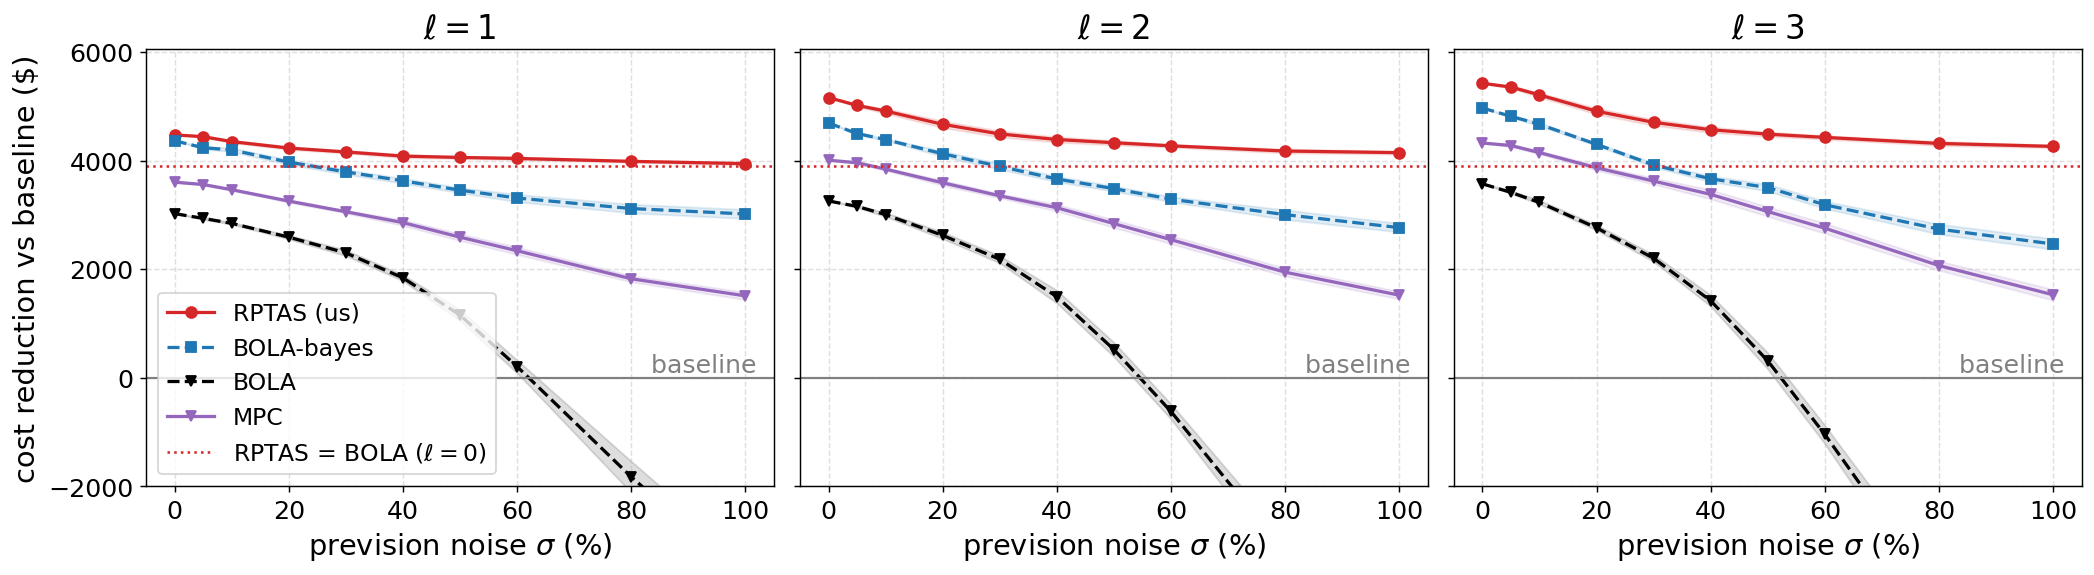

ecrit : fig_cost_reduction.pdf


In [46]:
import matplotlib.pyplot as plt

OUT_PDF = 'fig_cost_reduction.pdf'

# --- tailles typographiques (a ajuster ici uniquement) ---------------------
FS_TITLE, FS_LABEL, FS_TICK, FS_LEG = 18, 16, 14, 13
MS, LW = 6, 1.8
Y_BOTTOM = -2000            # troncature basse : BOLA sort du cadre au-dela

STYLE = {
    'rptas':      ('RPTAS (us)', 'tab:red', '-', 'o'),
    'bola_bayes': ('BOLA-bayes', 'tab:blue', '--', 's'),
    'mpc':        ('MPC', 'tab:purple', '-', 'v'),
    'bola':       ('BOLA', 'k', '--', 'v'),
}
xs = 100 * np.array(SIGMAS)

ELLS_PLOT = [e for e in ELLS if e != 0]          # panneau ell = 0 retire

fig, axes = plt.subplots(1, len(ELLS_PLOT), figsize=(5.4 * len(ELLS_PLOT), 4.5),
                         sharey=True)
for ax, ell in zip(np.atleast_1d(axes), ELLS_PLOT):
    for kk in POLICIES:
        lab, col, ls, mk = STYLE[kk]
        mu = np.array([base - res2['%s|%d|%.2f' % (kk, ell, sg)][0] for sg in SIGMAS])
        se = np.array([res2['%s|%d|%.2f' % (kk, ell, sg)][1] for sg in SIGMAS]) / np.sqrt(N_SEEDS)
        ax.plot(xs, mu, ls, marker=mk, ms=MS, lw=LW, color=col, label=lab)
        ax.fill_between(xs, mu - 2 * se, mu + 2 * se, color=col, alpha=.13)
    # plancher : la performance a ell = 0, i.e. sans aucune prevision
    ax.axhline(base - res2['rptas|0|0.00'][0], color='tab:red', ls=':', lw=1.4,
               label='RPTAS = BOLA ($\\ell=0$)' if ell == ELLS_PLOT[0] else None)
    ax.axhline(0, color='gray', lw=1.2)
    # etiquette de la ligne grise, calee a droite du panneau : x en
    # coordonnees d'axes (0 = bord gauche, 1 = bord droit), y en donnees.
    ax.text(0.985, 0, 'baseline ', fontsize=FS_TICK, color='gray',
            ha='right', va='bottom',
            transform=ax.get_yaxis_transform())
    ax.set_title('$\\ell = %d$' % ell, fontsize=FS_TITLE)
    ax.set_xlabel('prevision noise $\\sigma$ (%)', fontsize=FS_LABEL)
    ax.tick_params(axis='both', which='major', labelsize=FS_TICK)
    ax.grid(True, ls='--', alpha=.4)

# sharey=True : une seule borne suffit, elle se propage aux trois panneaux.
np.atleast_1d(axes)[0].set_ylim(bottom=Y_BOTTOM)

np.atleast_1d(axes)[0].set_ylabel('cost reduction vs baseline (\\$)', fontsize=FS_LABEL)
np.atleast_1d(axes)[0].legend(fontsize=FS_LEG, loc='best')
plt.tight_layout()
fig.savefig(OUT_PDF, bbox_inches='tight')
plt.show()
print('ecrit :', OUT_PDF)